In [1]:
import pandas as pd

# Load the dataset
file_path = "./clean data/co_concentrations.csv"
co_concentrations_df = pd.read_csv(file_path)

# Display the first few rows of the dataset
co_concentrations_df.head()

C:\ProgramData\Anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\ProgramData\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\ProgramData\Anaconda3\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


,Year,CO PPM,CO Percent
0,1992,356.545000,0.237500
1,1993,357.215000,0.187500
2,1994,358.959167,0.488333
3,1995,360.968333,0.560833
4,1996,362.743333,0.492500


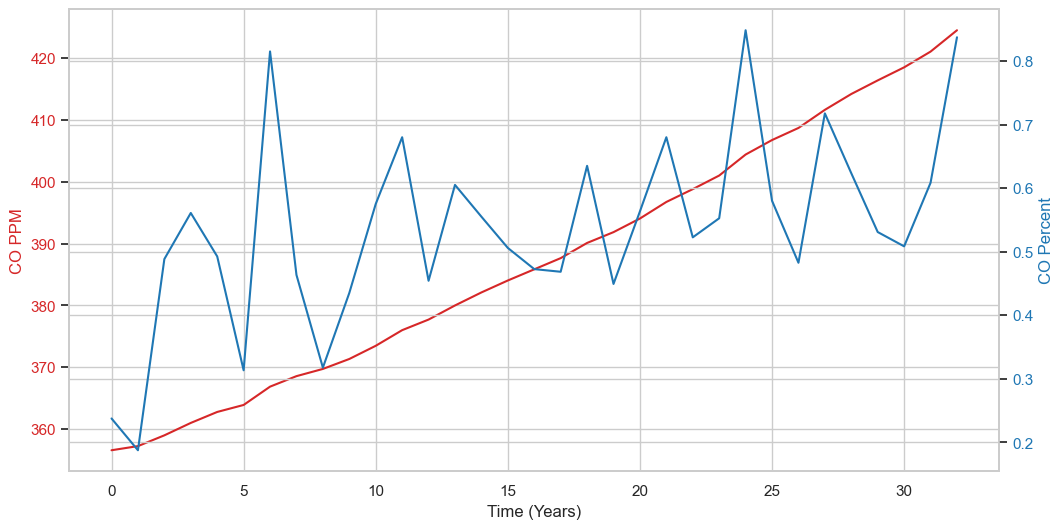

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting up the environment for visualization
sns.set(style="whitegrid")

# Trend Analysis: Plotting the trends in CO PPM and CO Percent over time
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Time (Years)')
ax1.set_ylabel('CO PPM', color=color)
ax1.plot(co_concentrations_df.index, co_concentrations_df['CO PPM'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:blue'
ax2.set_ylabel('CO Percent', color=color)  # we already handled the x-label with ax1
ax2.plot(co_concentrations_df.index, co_concentrations_df['CO Percent'], color=color)
ax2.tick_params(axis='y', labelcolor=color)

Text(0.5, 1.0, 'Distribution of CO Percent')

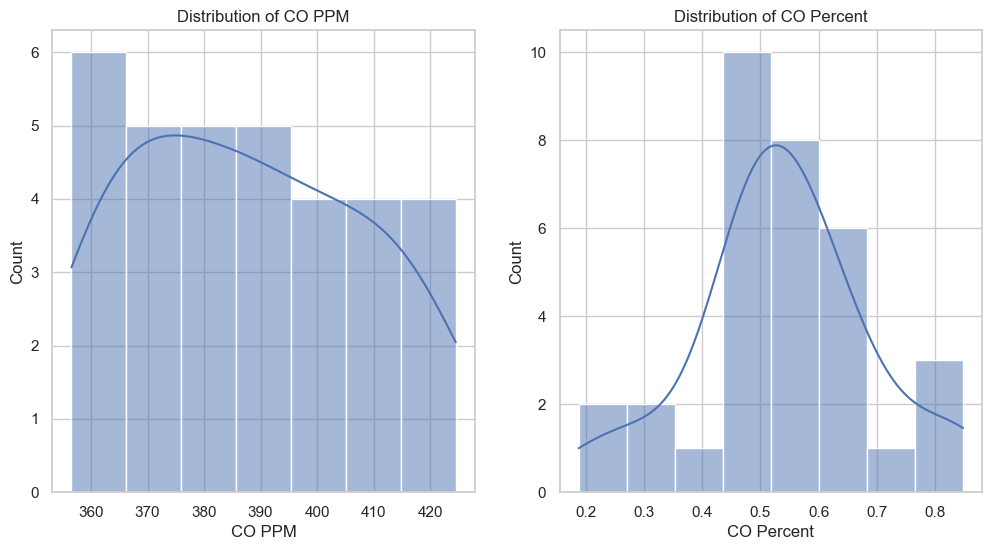

In [3]:
# Distribution Analysis: Histograms for CO PPM and CO Percent
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
sns.histplot(co_concentrations_df['CO PPM'], kde=True, ax=axs[0])
axs[0].set_title('Distribution of CO PPM')
sns.histplot(co_concentrations_df['CO Percent'], kde=True, ax=axs[1])
axs[1].set_title('Distribution of CO Percent')

In [4]:
# Load the new dataset
surface_temp_file_path = "./clean data/surface_temp_clean.csv"
surface_temp_df = pd.read_csv(surface_temp_file_path)

# Display the first few rows of the dataset to understand its structure
surface_temp_df.head()

,Country,Year,Temperature
0,"Afghanistan, Islamic Rep. of",1961,-0.126
1,Africa,1961,-0.017
2,Albania,1961,0.635
3,Algeria,1961,0.155
4,American Samoa,1961,0.121


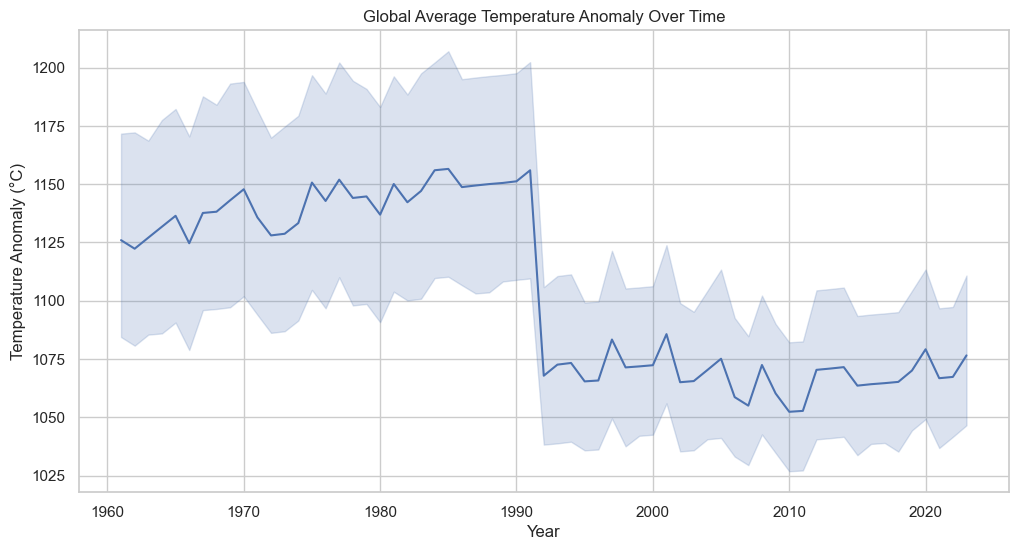

In [5]:
# Preparing data for global trend analysis
# Calculating the global average temperature anomaly for each year
surface_temp_df['Global Average'] = surface_temp_df.iloc[:, 1:].mean(axis=1)

# Global Trend Analysis: Plotting the global average temperature anomaly over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Global Average', data=surface_temp_df)
plt.title('Global Average Temperature Anomaly Over Time')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.show()

In [10]:
# Selected countries list with the appropriate names from the dataset
selected_countries =['United States', 'Brazil', 'India', 'Australia', 'China, P.R.: Mainland']

# Preparing the dataset for the country-specific analysis
country_specific_df = surface_temp_df[['Year'] + selected_countries]

# Plotting the temperature anomalies of the selected countries over time
plt.figure(figsize=(12, 6))
for country in selected_countries:
    sns.lineplot(x='Year', y=country, data=country_specific_df, label=country)
plt.title('Temperature Anomalies for Selected Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.legend()
plt.grid(True)
plt.show()

KeyError: "['United States', 'Brazil', 'India', 'Australia', 'China, P.R.: Mainland'] not in index"

In [11]:
# Load the new dataset
sea_level_file_path = "./clean data/sea_level_changes.csv"
sea_level_df = pd.read_csv(sea_level_file_path)

# Display the first few rows of the dataset to understand its structure
sea_level_df.head()

,Year,Adriatic Sea,Andaman Sea,Arabian Sea,Atlantic Ocean,Baltic Sea,Bay Bengal,Bering Sea,Caribbean Sea,Gulf Mexico,...,North Sea,Pacific Ocean,Persian Gulf,Sea Japan,Sea Okhotsk,South China,Southern Ocean,Tropics,World,Yellow Sea
0,1992,55.627500,49.662500,-27.800000,-7.297500,32.397500,1.785000,-9.355000,29.832500,25.140000,...,28.410000,-10.395000,42.405000,47.142500,-15.260000,35.077500,-22.062500,-12.237500,-16.980000,14.005000
1,1993,-44.092353,-13.391176,-1.773529,-18.451176,-35.854706,-9.998824,-8.047647,-12.618235,-8.521765,...,-12.742941,-18.655294,-19.502353,-31.314118,-22.727647,-41.198235,-21.302941,-19.679412,-19.515294,-33.861176
2,1994,-15.201176,-46.644118,-1.000000,-14.960000,-11.372353,-20.913529,-9.874118,4.990588,-16.262941,...,-18.584118,-13.046471,1.206471,-5.090588,-17.860000,-36.115882,-17.141176,-16.079412,-14.818235,-7.620000
3,1995,-19.145484,-0.496875,3.837500,-8.192258,26.719375,1.188125,16.105484,-4.092903,-1.619375,...,3.219375,-10.195806,-1.201250,-17.354375,6.255625,-24.168065,-11.835484,-9.558065,-9.396129,-30.776452
4,1996,3.172353,11.837879,-6.553030,-7.121765,-107.402121,3.649394,35.661176,-18.427059,-32.423636,...,-34.576364,-5.246471,7.701212,-23.850303,11.711212,-12.504118,-9.185294,-4.570588,-5.847647,-17.937647


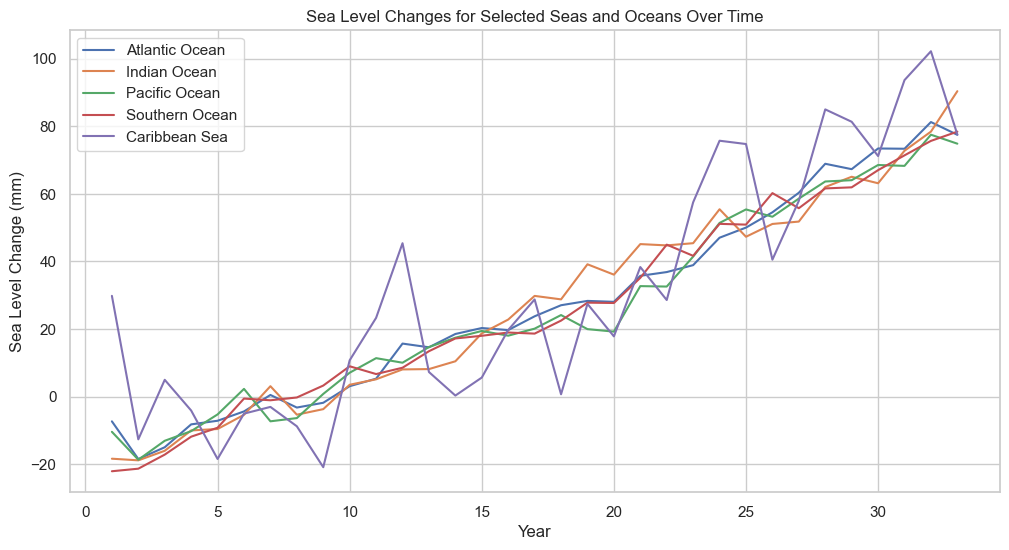

In [12]:
# Preparing data for trend analysis and global sea level change analysis
# Assuming the rows are ordered chronologically, we will add a 'Year' column for visualization purposes
sea_level_df['Year'] = range(1, len(sea_level_df) + 1)

# Selecting a few seas and oceans for trend analysis
selected_seas = ['Atlantic Ocean', 'Indian Ocean', 'Pacific Ocean', 'Southern Ocean', 'Caribbean Sea']

# Trend Analysis: Plotting the sea level changes of selected seas and oceans over time
plt.figure(figsize=(12, 6))
for sea in selected_seas:
    sns.lineplot(x='Year', y=sea, data=sea_level_df, label=sea)
plt.title('Sea Level Changes for Selected Seas and Oceans Over Time')
plt.xlabel('Year')
plt.ylabel('Sea Level Change (mm)')
plt.legend()
plt.grid(True)
plt.show()

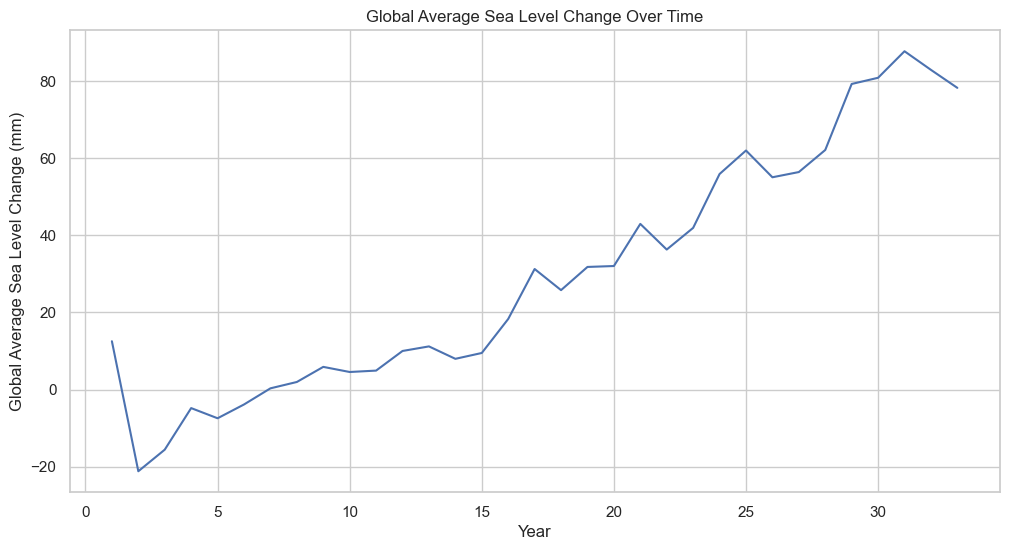

In [13]:
# Global Sea Level Change Analysis: Calculating and plotting the global average sea level change over time
sea_level_df['Global Average'] = sea_level_df.iloc[:, :-2].mean(axis=1)
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Global Average', data=sea_level_df)
plt.title('Global Average Sea Level Change Over Time')
plt.xlabel('Year')
plt.ylabel('Global Average Sea Level Change (mm)')
plt.grid(True)
plt.show()

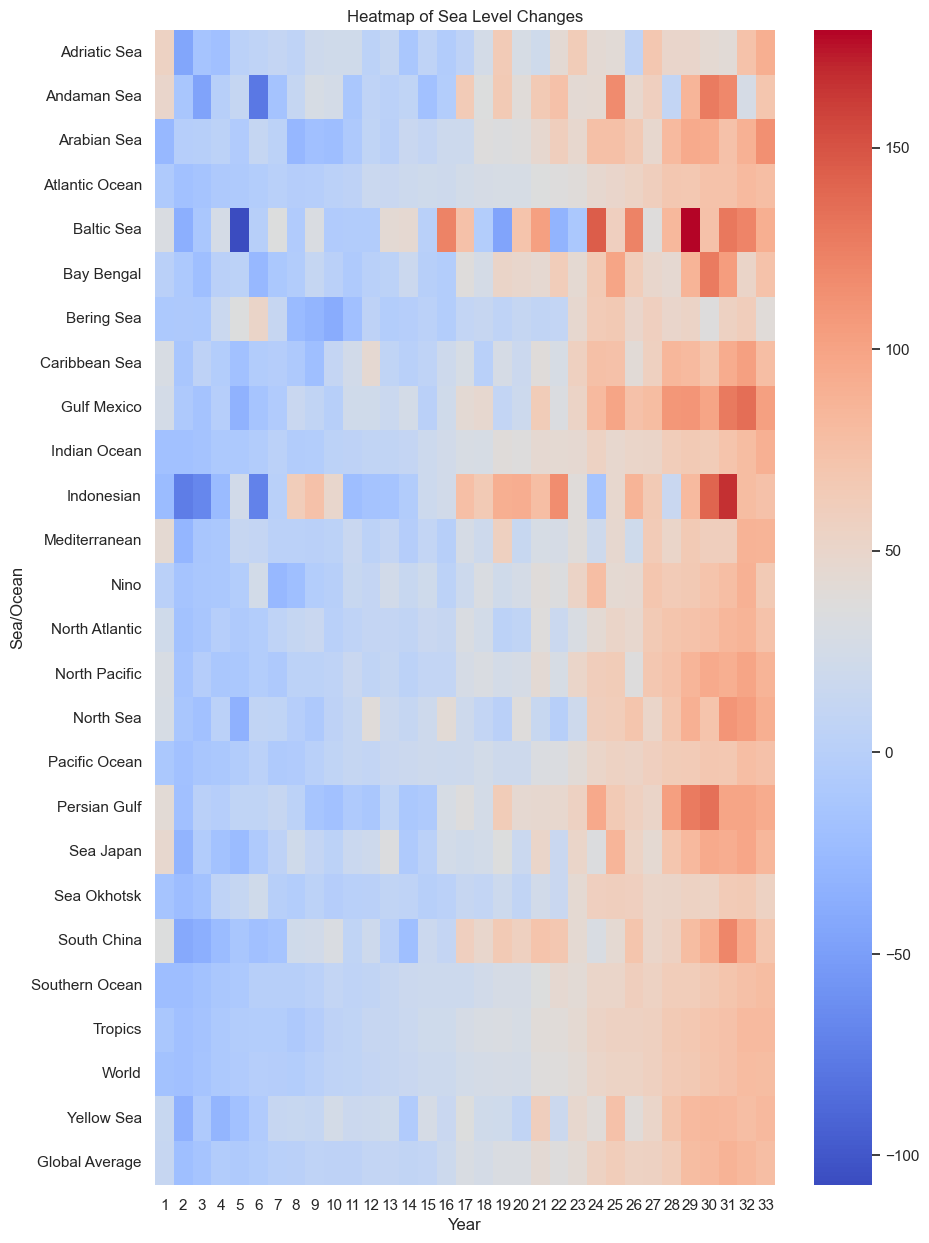

In [14]:
# Heatmap Analysis: Creating a heatmap for the dataset
heatmap_data = sea_level_df.drop('Year', axis=1).transpose()
heatmap_data.columns = sea_level_df['Year']
plt.figure(figsize=(10, 15))
sns.heatmap(heatmap_data, cmap='coolwarm', yticklabels=True)
plt.title('Heatmap of Sea Level Changes')
plt.ylabel('Sea/Ocean')
plt.xlabel('Year')
plt.show()

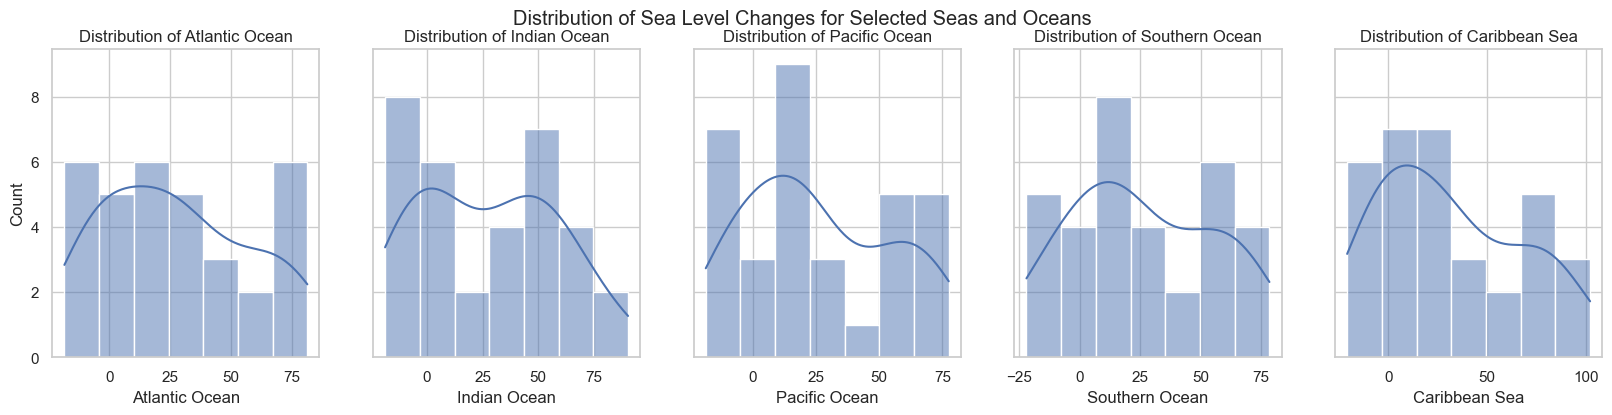

In [15]:
# Distribution Analysis: Histograms for selected seas and oceans
fig, axs = plt.subplots(1, len(selected_seas), figsize=(20, 4), sharey=True)
for i, sea in enumerate(selected_seas):
    sns.histplot(sea_level_df[sea], kde=True, ax=axs[i])
    axs[i].set_title(f'Distribution of {sea}')
plt.suptitle('Distribution of Sea Level Changes for Selected Seas and Oceans')
plt.show()

In [16]:
# Load the new dataset
climate_disasters_file_path = "./clean data/climate_disasters_clean.csv"
climate_disasters_df = pd.read_csv(climate_disasters_file_path)

# Display the first few rows of the dataset to understand its structure
climate_disasters_df.head()

,Year,Country,Drought,Extreme temperature,Flood,Landslide,Storm,TOTAL,Wildfire
0,1980,"Afghanistan, Islamic Rep. of",0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1980,Albania,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1980,Algeria,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1980,All Countries and International Organizations,0.0,0.0,0.0,0.0,0.0,107.0,0.0
4,1980,American Samoa,0.0,0.0,0.0,0.0,0.0,0.0,0.0


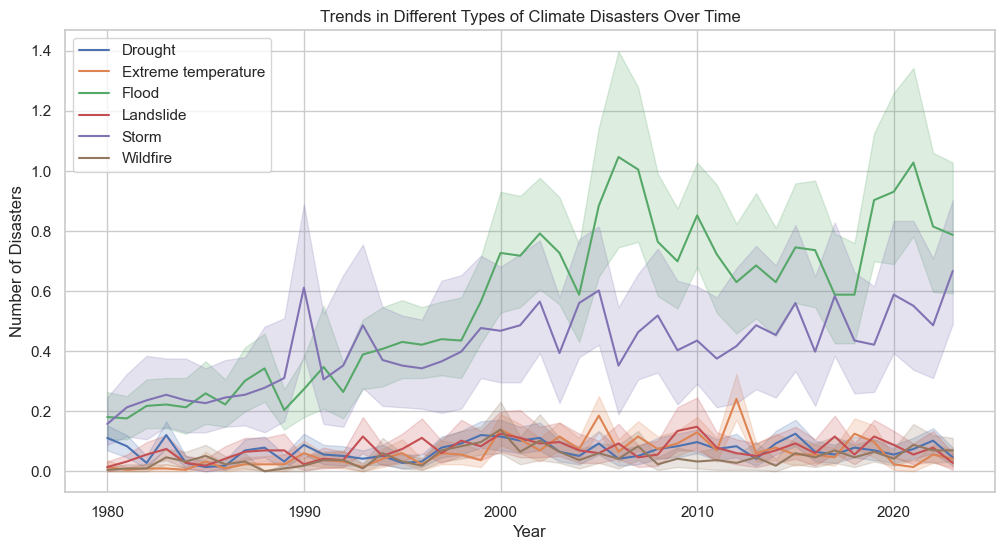

In [17]:
# Trend Analysis: Plotting the trends in different types of climate disasters over time
disaster_types = ['Drought', 'Extreme temperature', 'Flood', 'Landslide', 'Storm', 'Wildfire']

plt.figure(figsize=(12, 6))
for disaster in disaster_types:
    sns.lineplot(x='Year', y=disaster, data=climate_disasters_df, label=disaster)
plt.title('Trends in Different Types of Climate Disasters Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Disasters')
plt.legend()
plt.grid(True)
plt.show()

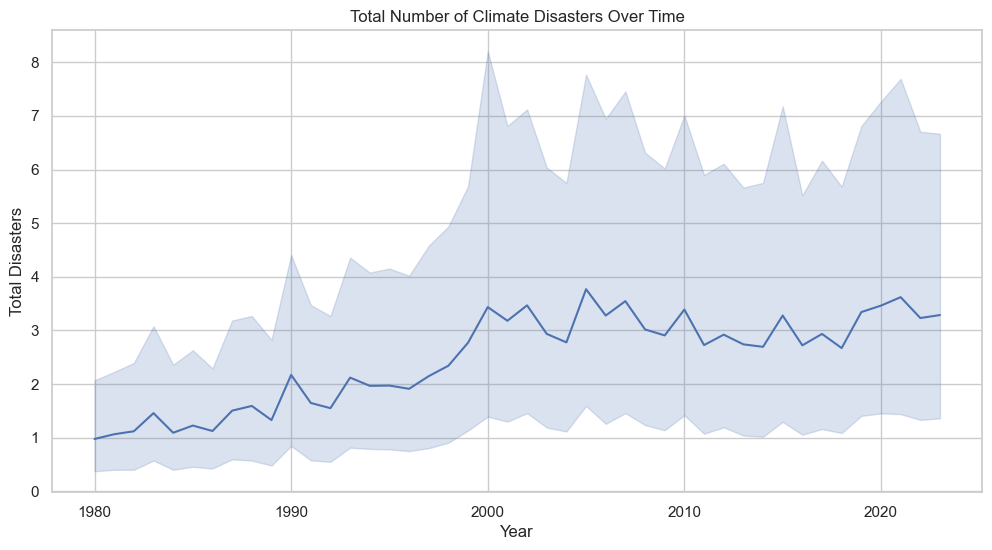

In [18]:
# Total Disaster Trend Analysis: Analyzing the trend in the total number of climate disasters over time
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='TOTAL', data=climate_disasters_df)
plt.title('Total Number of Climate Disasters Over Time')
plt.xlabel('Year')
plt.ylabel('Total Disasters')
plt.grid(True)
plt.show()

In [22]:
# Heatmap Analysis: Creating a heatmap for the dataset
heatmap_data = climate_disasters_df.set_index('Year')
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='coolwarm', annot=True, fmt=".0f")
plt.title('Heatmap of Climate Disasters Frequency by Year')
plt.ylabel('Year')
plt.xlabel('Disaster Type')
plt.show()

ValueError: could not convert string to float: 'Afghanistan, Islamic Rep. of'

<Figure size 1000x800 with 0 Axes>

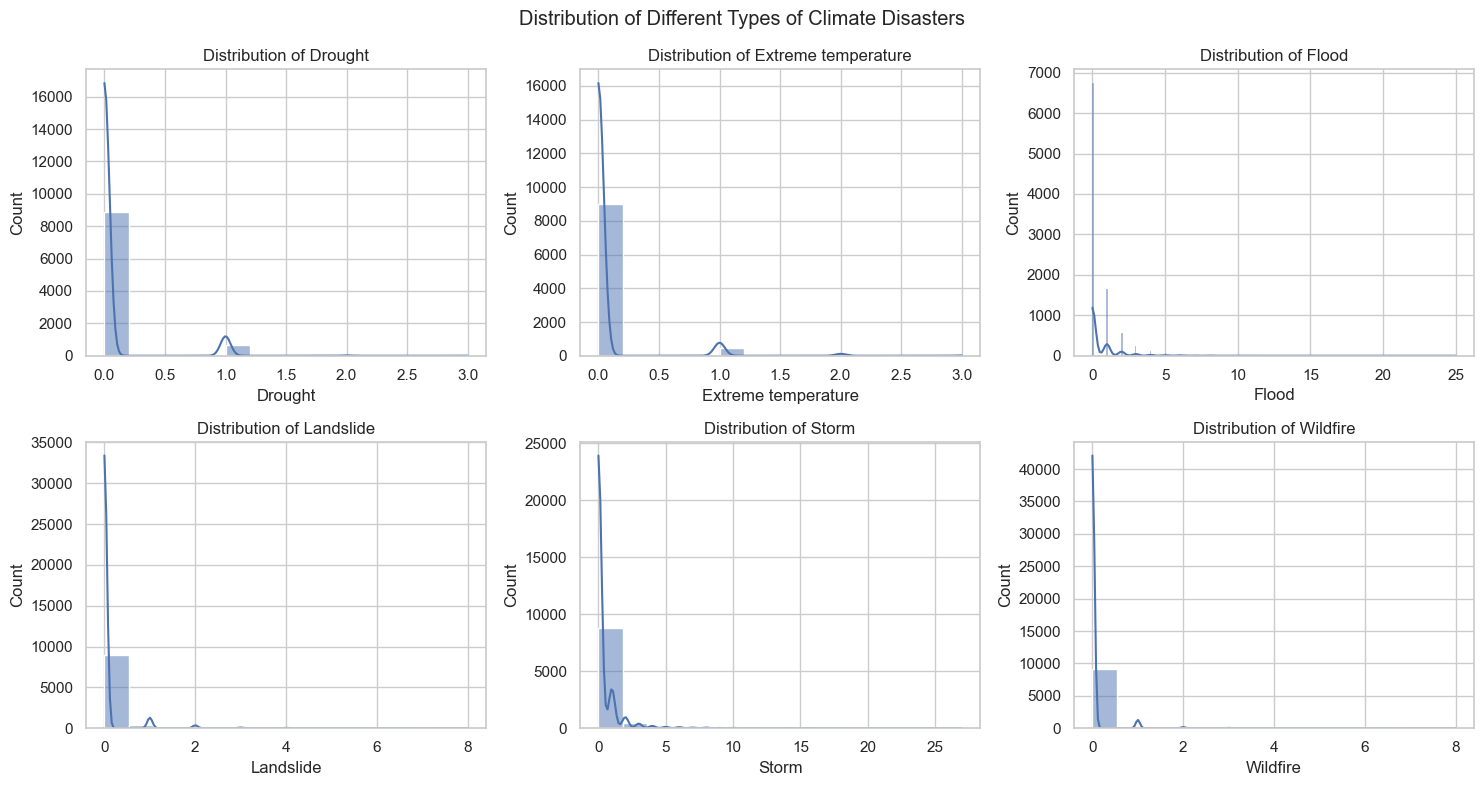

In [23]:
# Distribution Analysis: Histograms for each disaster type
fig, axs = plt.subplots(2, 3, figsize=(15, 8))
for i, disaster in enumerate(disaster_types):
    row = i // 3
    col = i % 3
    sns.histplot(climate_disasters_df[disaster], kde=True, ax=axs[row, col])
    axs[row, col].set_title(f'Distribution of {disaster}')
plt.suptitle('Distribution of Different Types of Climate Disasters')
plt.tight_layout()
plt.show()